# TTS Tutorial Remake with SLR80 Dataset

## Original
- **Prepared by:** Ye Kyaw Thu, Language Understanding Lab., Myanmar
- **Last Updated Date:** 20 June 2026
- **Reason:** *For AI Engineering (Fundamental) class students*

## Remake: Experiment Version 2.0
This remake follows the same tutorial flow but with NAR (non-autoregressive) approach.

## Setup

In [1]:
from pathlib import Path
import IPython.display as ipd
from IPython.display import Image

current_dir = Path.cwd()
SCRIPTS = current_dir / "scripts"
SRC = current_dir / "src"
OUTPUT = current_dir / "tts_output/nar_version"
GT_PATH = OUTPUT / "gt_output"
PLOTS = OUTPUT / "plots"

## Download Dataset: SLR80

In [2]:
# skip if data already downloaded
# !time {SCRIPTS}/download_dataset.sh

In [3]:
!tree ./data/ | head -n 10

./data/
└── slr80
    ├── bur_0366_0045318711.wav
    ├── bur_0366_0096392289.wav
    ├── bur_0366_0178258874.wav
    ├── bur_0366_0235517782.wav
    ├── bur_0366_0432235369.wav
    ├── bur_0366_0445549145.wav
    ├── bur_0366_0446483510.wav
    ├── bur_0366_0469985799.wav


In [4]:
!head ./data/slr80/line_index_female.tsv

bur_7865_1250917969	ပြီးတော့ တရုတ် နဲ့လည်း ချစ်ကြည်ရင်းနှီးတဲ့ ဆက်ဆံရေး ရှိတယ်
bur_8698_6883351313	အဲ့ဒီ ဝေဖန်မှုတွေ နဲ့ ပတ်သက် လို့ ဘယ်လို တုံ့ပြန်ချင်ပါသလဲ
bur_3260_8853590661	မမီ မွေးဖွားနေတဲ့ အချိန် မှာတော့ ဘုရား ဂုဏ်တော် ကိုပဲ တောက်လျှောက် ရွတ်နေခဲ့ပါတယ်
bur_2446_1980151079	ခင်ဦးသာ နှင့် နန်းလွင်နှင်းပွင့် ပူးပေါင်း ရေးသားသည်
bur_5189_8958061789	ကြည့်ရသည်မှာ မြန်မာ နိုင်ငံ တွင် သူ့ အတွက် ခိုလှုံရာ တခု တွေ့ခဲ့ပုံ ရပါသည်
bur_6884_6350507293	မမဖွေးဖွေး နဲ့ တွေ့ရ တော့ တအား ပျော်တယ် လို့ ပြောပါတယ်
bur_5362_7563127136	အထူးသဖြင့် နိုင်ငံရေး လောက ကို စုစည်းနိုင်ခဲ့သည် ဟု ဆိုနိုင်ပါသည်
bur_7543_6156096513	ကဖင်း မပါဝင်သော ကော်ဖီ သောက်ပါ
bur_8266_0671510151	ကောလင်း မြို့နယ် ရေကြီးတာ က ဆည်ကျိုး လို့ မဟုတ်ဘူး
bur_6118_8081481703	ကျွန်မ အလုပ် ကို လေးလေးစားစား လုပ်ပါတယ်


In [5]:
!head ./data/slr80/line_index.tsv

bur_7865_1250917969	ပြီးတော့ တရုတ် နဲ့လည်း ချစ်ကြည်ရင်းနှီးတဲ့ ဆက်ဆံရေး ရှိတယ်
bur_8698_6883351313	အဲ့ဒီ ဝေဖန်မှုတွေ နဲ့ ပတ်သက် လို့ ဘယ်လို တုံ့ပြန်ချင်ပါသလဲ
bur_3260_8853590661	မမီ မွေးဖွားနေတဲ့ အချိန် မှာတော့ ဘုရား ဂုဏ်တော် ကိုပဲ တောက်လျှောက် ရွတ်နေခဲ့ပါတယ်
bur_2446_1980151079	ခင်ဦးသာ နှင့် နန်းလွင်နှင်းပွင့် ပူးပေါင်း ရေးသားသည်
bur_5189_8958061789	ကြည့်ရသည်မှာ မြန်မာ နိုင်ငံ တွင် သူ့ အတွက် ခိုလှုံရာ တခု တွေ့ခဲ့ပုံ ရပါသည်
bur_6884_6350507293	မမဖွေးဖွေး နဲ့ တွေ့ရ တော့ တအား ပျော်တယ် လို့ ပြောပါတယ်
bur_5362_7563127136	အထူးသဖြင့် နိုင်ငံရေး လောက ကို စုစည်းနိုင်ခဲ့သည် ဟု ဆိုနိုင်ပါသည်
bur_7543_6156096513	ကဖင်း မပါဝင်သော ကော်ဖီ သောက်ပါ
bur_8266_0671510151	ကောလင်း မြို့နယ် ရေကြီးတာ က ဆည်ကျိုး လို့ မဟုတ်ဘူး
bur_6118_8081481703	ကျွန်မ အလုပ် ကို လေးလေးစားစား လုပ်ပါတယ်


## Prepare Dataset: SLR80

Original:
```Python
!time python {SRC}/myanmar_tts_transformer.py --stage prep \
  --data_dir ./data/slr80 \
  --output_dir ./tts_output
```

NAR version:
```Python
!time python {SRC}/myanmar_tts_transformer_nar.py --stage prep \
  --data_dir ./data/slr80 \
  --output_dir ./tts_output/nar_version
```

In [6]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage prep \
  --data_dir ./data/slr80 \
  --output_dir {OUTPUT}

2026-09-25 02:10:01  [INFO    ]  Found 2530 audio files.
2026-09-25 02:10:01  [INFO    ]  Vocabulary: 66 characters
2026-09-25 02:10:01  [INFO    ]  Computing mel spectrograms ...
2026-09-25 02:10:11  [INFO    ]    500/2530 ...
2026-09-25 02:10:18  [INFO    ]    1000/2530 ...
2026-09-25 02:10:26  [INFO    ]    1500/2530 ...
2026-09-25 02:10:34  [INFO    ]    2000/2530 ...
2026-09-25 02:10:42  [INFO    ]    2500/2530 ...
2026-09-25 02:10:42  [INFO    ]  Valid: 2530 | Skipped: 0
2026-09-25 02:10:42  [INFO    ]  Mel norm check: min=-1.000 max=1.000 mean=-0.481
2026-09-25 02:10:42  [INFO    ]  Mel frames : mean=504 ± 150
2026-09-25 02:10:42  [INFO    ]  Frames/char: mean=7.3 ± 1.6
2026-09-25 02:10:42  [INFO    ]    train: 2024
2026-09-25 02:10:42  [INFO    ]    dev: 253
2026-09-25 02:10:42  [INFO    ]    test: 253
2026-09-25 02:10:42  [INFO    ]  Data preparation complete ✓

real	0m46.323s
user	7m25.987s
sys	0m2.502s


In [7]:
!time python {SRC}/get_real_durations.py \
  --output_dir {OUTPUT} \
  --lang mya

Loading facebook/mms-1b-all (adapter='mya') — first run downloads weights...
Loading weights: 100%|███████████████████| 1096/1096 [00:00<00:00, 2049.72it/s]
  CTC dim=140  tokenizer_vocab=141  pad/blank=0
Aligning train.json (2024 utterances)...
  aligned OK: 2024   fell back to proportional: 0
  wrote tts_output/nar_version/train_real_durations.json
Aligning dev.json (253 utterances)...
  aligned OK: 253   fell back to proportional: 0
  wrote tts_output/nar_version/dev_real_durations.json

Done. Inspect a few *_real_durations.json entries, then:
  cp train.json train_proportional_backup.json
  cp dev.json dev_proportional_backup.json
  cp train_real_durations.json train.json
  cp dev_real_durations.json dev.json
  python src/myanmar_tts_transformer_nar.py --stage train --output_dir ...

real	16m19.282s
user	19m9.380s
sys	0m6.068s


In [8]:
!time python {SRC}/plot.py durations --output_dir {OUTPUT} --split train

split=train  inspected=500/2024
  sum(durations)==mel_frames : 500/500
  mid-duration std  mean=4.00  median=3.81
  near-uniform (≤3 distinct >0 values): 239/500  (high ⇒ looks proportional)
  example id=bur_8266_7413365509
    top counts: [(8, 30), (7, 20), (15, 10), (0, 8)]
    std=3.87  min=0  max=15
saved → tts_output/nar_version/plots/durations_train.png

real	0m1.020s
user	0m2.155s
sys	0m0.067s


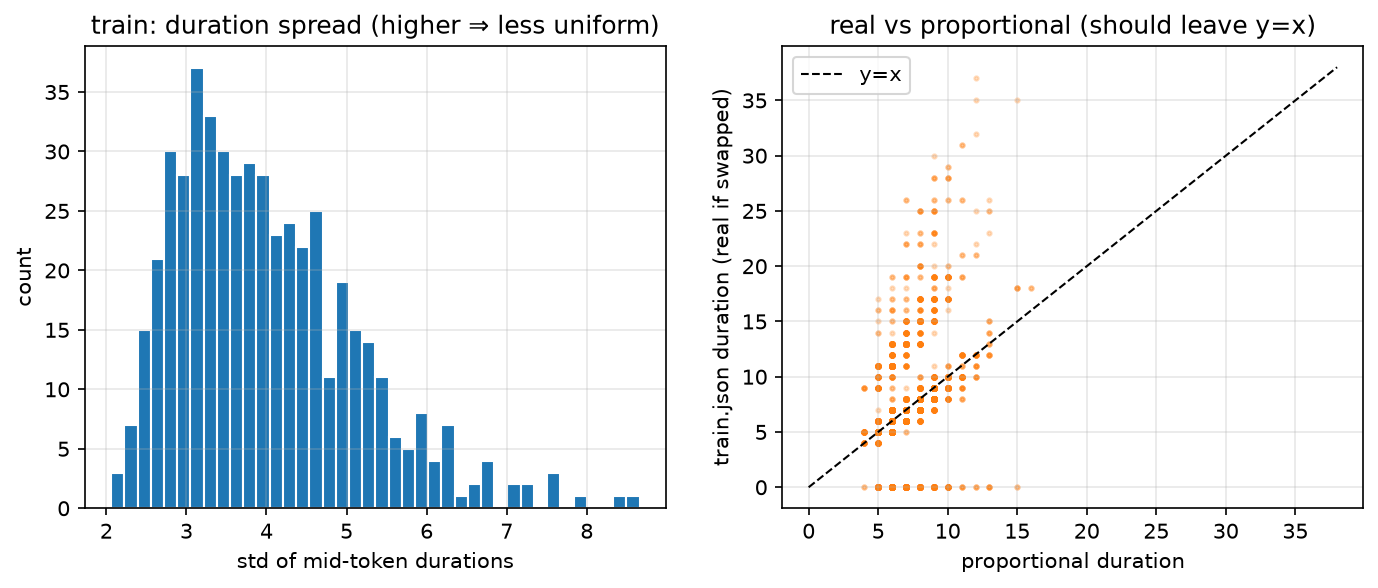

In [9]:
ipd.display(Image(filename=f"{PLOTS}/durations_train.png"))

## Backup & Replace

In [10]:
# backup original train and dev files
!cp {OUTPUT}/train.json {OUTPUT}/train_proportional_backup.json
!cp {OUTPUT}/dev.json {OUTPUT}/dev_proportional_backup.json

# use duration files for train and dev
!cp {OUTPUT}/train_real_durations.json {OUTPUT}/train.json
!cp {OUTPUT}/dev_real_durations.json {OUTPUT}/dev.json

## Model Training

Original:
```Python
!time python {SRC}/myanmar_tts_transformer.py --stage train \
  --output_dir ./tts_output \
  --epochs 300
```

NAR version:
```Python
!time python {SRC}/myanmar_tts_transformer_nar.py --stage train \
  --output_dir ./tts_output/nar_version \
  --epochs 300 \
  --batch_size 8 \
  --dur_loss_weight 1.0
```

v6 experiment 1.0 version:
```python
!time python {SRC}/myanmar_tts_transformer_v6.py --stage train \
  --output_dir ./tts_output/v6 \
  --epochs 300 \
  --batch_size 8 \
  --ga_weight 1.0 --ga_g 0.2 \
  --ss_start_epoch 50 \
  --ss_max_prob 0.5
```

v6 experiment 1.1 version:
```python
!time python {SRC}/myanmar_tts_transformer_v6.py --stage train \
  --output_dir "./tts_output/v6_exp_1.1" \
  --epochs 130 \
  --batch_size 8 \
  --ga_weight 3.0 --ga_g 0.15 \
  --ss_start_epoch 20 \
  --ss_max_prob 0.8
```

v6 experiment 1.2 version:
```python
!time python {SRC}/myanmar_tts_transformer_v6.py --stage train \
  --output_dir "./tts_output/v6_exp_1.2" \
  --epochs 50 \
  --batch_size 8 \
  --ga_weight 5.0 --ga_g 0.1 \
  --ss_start_epoch 10 \
  --ss_max_prob 0.8
```

v6 experiment 1.3 version:
```python
!time python {SRC}/myanmar_tts_transformer_v6.py --stage train \
  --output_dir "./tts_output/v6_exp_1.3" \
  --epochs 50 \
  --batch_size 8 \
  --ga_weight 8.0 --ga_g 0.08 \
  --ss_start_epoch 10 \
  --ss_max_prob 0.8
```

In [11]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage train \
  --output_dir {OUTPUT} \
  --epochs 50 \
  --batch_size 8 \
  --dur_loss_weight 1.0

2026-09-25 04:39:43  [INFO    ]  Vocab:66  Train:2024  Dev:253
2026-09-25 04:39:43  [INFO    ]  Device: cuda
2026-09-25 04:39:44  [INFO    ]  TransformerTTSNAR parameters: 44,653,121
2026-09-25 04:39:45  [INFO    ]  Training 50 epochs (warmup=20, lr=1.0e-03)
2026-09-25 04:39:45  [INFO    ]  Architecture: TransformerTTSNAR (FastSpeech2-style)
2026-09-25 04:39:45  [INFO    ]    encoder -> duration predictor -> length regulator -> NAR decoder
2026-09-25 04:39:45  [INFO    ]    duration loss weight = 1.0
2026-09-25 04:39:45  [INFO    ]  Forced durations: proportional char->mel (or sample['durations'])
2026-09-25 04:42:57  [INFO    ]  Epoch    1/50 | train=1.6953  dev=1.1940 | lr=1.00e-04
2026-09-25 04:42:58  [INFO    ]    ✓ Best model saved (dev=1.1940)
2026-09-25 04:46:10  [INFO    ]  Epoch    2/50 | train=1.2865  dev=1.2011 | lr=1.50e-04
2026-09-25 04:49:22  [INFO    ]  Epoch    3/50 | train=1.2744  dev=1.1793 | lr=2.00e-04
2026-09-25 04:49:23  [INFO    ]    ✓ Best model saved (dev=1.179

In [12]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage train \
  --output_dir {OUTPUT} \
  --epochs 150 \
  --batch_size 8 \
  --dur_loss_weight 1.0 \
  --resume {OUTPUT}/checkpoint_ep0050.pt

2026-09-25 16:00:32  [INFO    ]  Vocab:66  Train:2024  Dev:253
2026-09-25 16:00:32  [INFO    ]  Device: cuda
2026-09-25 16:00:32  [INFO    ]  TransformerTTSNAR parameters: 44,653,121
2026-09-25 16:00:34  [INFO    ]  Resumed from epoch 50 (best dev=1.1272)
2026-09-25 16:00:34  [INFO    ]  Training 150 epochs (warmup=20, lr=1.0e-03)
2026-09-25 16:00:34  [INFO    ]  Architecture: TransformerTTSNAR (FastSpeech2-style)
2026-09-25 16:00:34  [INFO    ]    encoder -> duration predictor -> length regulator -> NAR decoder
2026-09-25 16:00:34  [INFO    ]    duration loss weight = 1.0
2026-09-25 16:00:34  [INFO    ]  Forced durations: proportional char->mel (or sample['durations'])
2026-09-25 16:08:41  [INFO    ]  Epoch   51/150 | train=1.0358  dev=1.1316 | lr=8.73e-04
2026-09-25 16:16:50  [INFO    ]  Epoch   52/150 | train=1.1054  dev=1.1395 | lr=8.65e-04
2026-09-25 16:24:56  [INFO    ]  Epoch   53/150 | train=1.1329  dev=1.1578 | lr=8.57e-04
2026-09-25 16:33:05  [INFO    ]  Epoch   54/150 | trai

In [13]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage train \
  --output_dir {OUTPUT} \
  --epochs 150 \
  --batch_size 8 \
  --dur_loss_weight 1.0 \
  --resume {OUTPUT}/checkpoint_ep0130.pt

2026-09-26 11:50:29  [INFO    ]  Vocab:66  Train:2024  Dev:253
2026-09-26 11:50:29  [INFO    ]  Device: cuda
2026-09-26 11:50:30  [INFO    ]  TransformerTTSNAR parameters: 44,653,121
2026-09-26 11:50:36  [INFO    ]  Resumed from epoch 130 (best dev=1.1272)
2026-09-26 11:50:36  [INFO    ]  Training 150 epochs (warmup=20, lr=1.0e-03)
2026-09-26 11:50:36  [INFO    ]  Architecture: TransformerTTSNAR (FastSpeech2-style)
2026-09-26 11:50:36  [INFO    ]    encoder -> duration predictor -> length regulator -> NAR decoder
2026-09-26 11:50:36  [INFO    ]    duration loss weight = 1.0
2026-09-26 11:50:36  [INFO    ]  Forced durations: proportional char->mel (or sample['durations'])
2026-09-26 11:58:42  [INFO    ]  Epoch  131/150 | train=1.0601  dev=1.1386 | lr=9.92e-05
2026-09-26 12:06:52  [INFO    ]  Epoch  132/150 | train=1.0600  dev=1.1413 | lr=9.42e-05
2026-09-26 12:15:00  [INFO    ]  Epoch  133/150 | train=1.0588  dev=1.1408 | lr=8.95e-05
2026-09-26 12:23:10  [INFO    ]  Epoch  134/150 | tra

In [14]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage train \
  --output_dir {OUTPUT} \
  --epochs 150 \
  --batch_size 8 \
  --dur_loss_weight 1.0 \
  --resume {OUTPUT}/checkpoint_ep0140.pt

2026-09-26 13:20:35  [INFO    ]  Vocab:66  Train:2024  Dev:253
2026-09-26 13:20:35  [INFO    ]  Device: cuda
2026-09-26 13:20:36  [INFO    ]  TransformerTTSNAR parameters: 44,653,121
2026-09-26 13:20:38  [INFO    ]  Resumed from epoch 140 (best dev=1.1272)
2026-09-26 13:20:38  [INFO    ]  Training 150 epochs (warmup=20, lr=1.0e-03)
2026-09-26 13:20:38  [INFO    ]  Architecture: TransformerTTSNAR (FastSpeech2-style)
2026-09-26 13:20:38  [INFO    ]    encoder -> duration predictor -> length regulator -> NAR decoder
2026-09-26 13:20:38  [INFO    ]    duration loss weight = 1.0
2026-09-26 13:20:38  [INFO    ]  Forced durations: proportional char->mel (or sample['durations'])
2026-09-26 13:23:46  [INFO    ]  Epoch  141/150 | train=1.0488  dev=1.1443 | lr=6.12e-05
2026-09-26 13:26:54  [INFO    ]  Epoch  142/150 | train=1.0478  dev=1.1456 | lr=5.88e-05
2026-09-26 13:30:02  [INFO    ]  Epoch  143/150 | train=1.0470  dev=1.1473 | lr=5.68e-05
2026-09-26 13:33:11  [INFO    ]  Epoch  144/150 | tra

## Model Training Results

In [15]:
!time python {SRC}/plot.py loss \
  --output_dir {OUTPUT} \
  --save {PLOTS}/loss.png

loaded 150 epochs from /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/train_log.json
saved → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/plots/loss.png

real	0m1.031s
user	0m2.127s
sys	0m0.068s


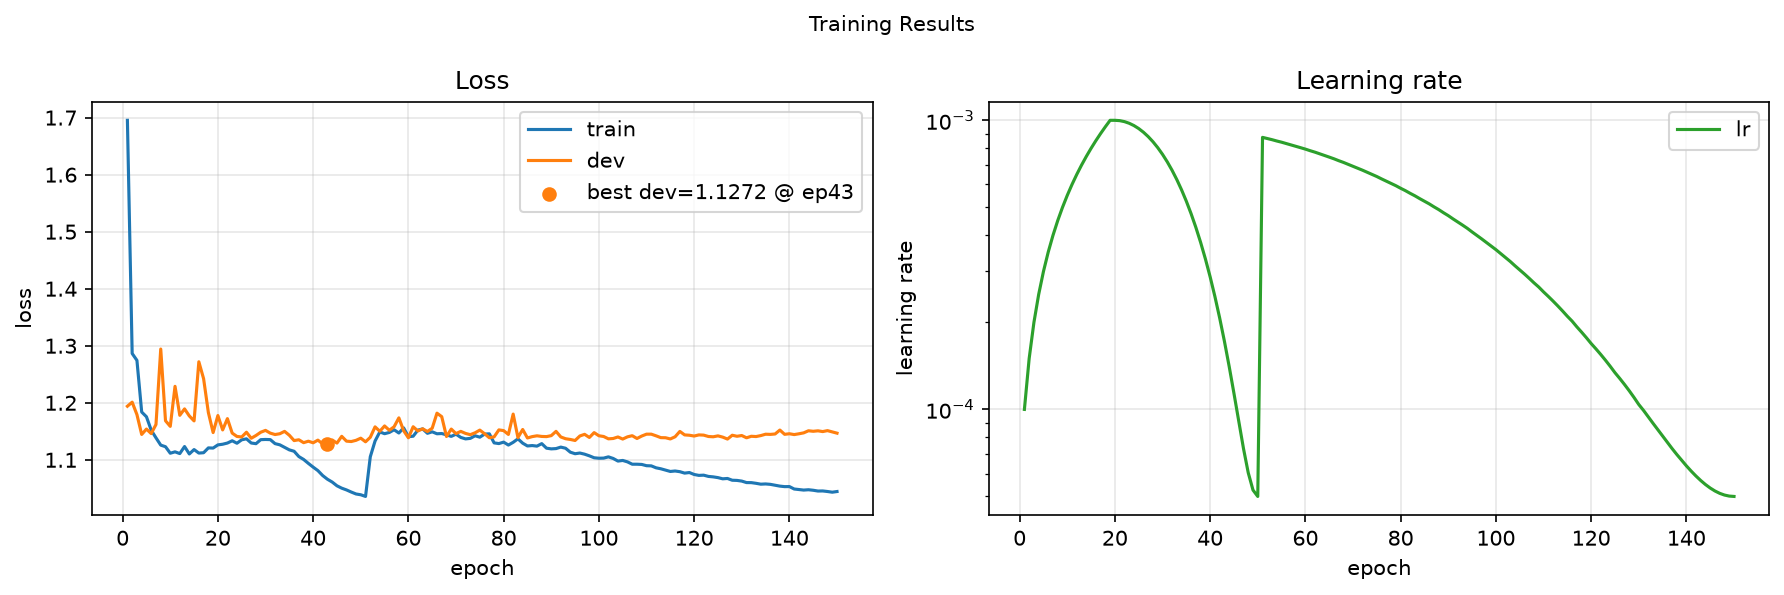

In [16]:
ipd.display(Image(filename=f"{PLOTS}/loss.png"))

## Check Samples

In [17]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage synth \
  --output_dir {OUTPUT} \
  --list_samples

/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/anaconda3/envs/lu_aief_asr_tts_env/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/lawun330/anaconda3/envs/lu_aief_asr_tts_env/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:145: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
2026-09

## Check Vocoders

Install Myanmar font via:
```bash
sudo apt update
sudo apt install python3-gi python3-gi-cairo gir1.2-pango-1.0

# alternatively
sudo apt install fonts-sil-padauk fonts-noto-core
```

### Example Sample 1 - HiFi-GAN

In [18]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage synth \
  --output_dir {OUTPUT} \
  --gt_sample_id bur_5362_4875790905 \
  --synth_out {GT_PATH}/gt_bur_5362_4875790905.wav

/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/anaconda3/envs/lu_aief_asr_tts_env/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:145: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
HiFi-GAN: Removing weight norm.
2026-09-26 18:25:56  [INFO    ]  HiFi-GAN loaded ✓  (NVIDIA torch.hub)
2026-09-26 18:25:56  [INFO    ]  Found bur_5362_4875790905 in train
2026-09-26 18:25:56  [INFO    ]  GT text: ကျွန်တော် ကလည်း ဒိ

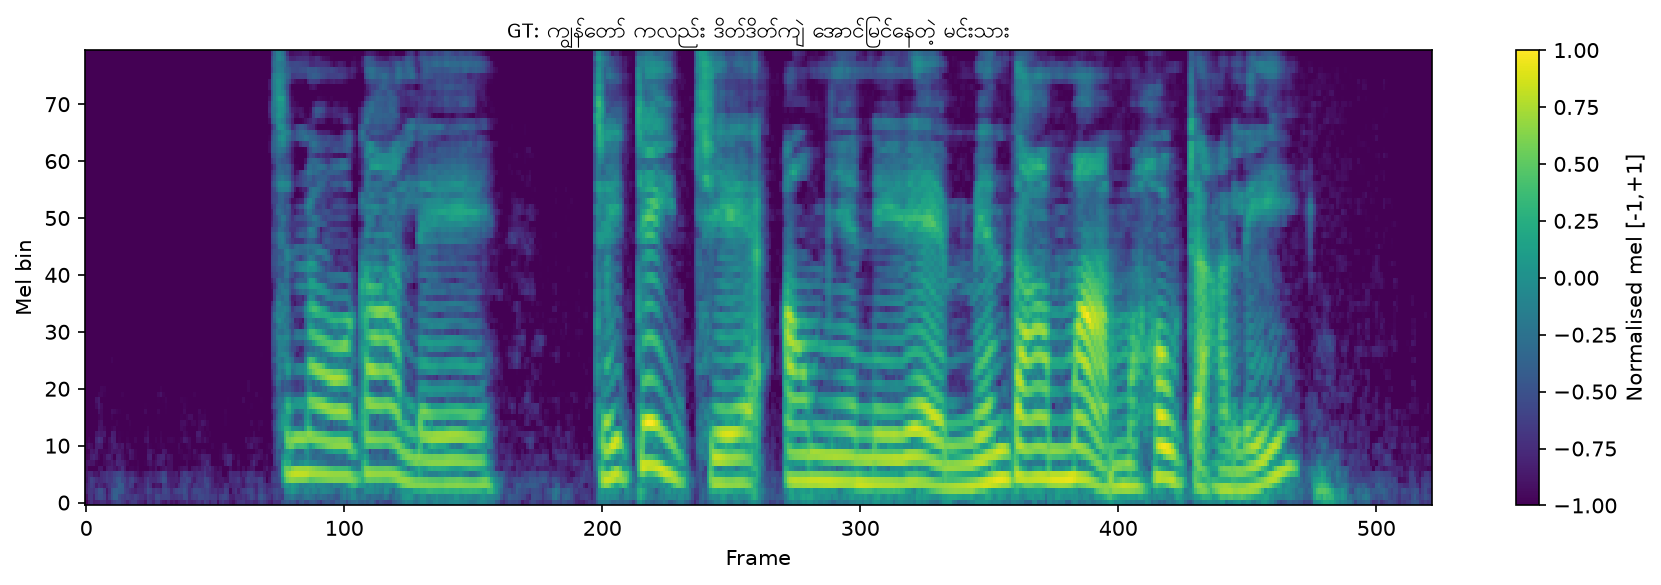

In [19]:
ipd.display(ipd.Audio(f"{GT_PATH}/gt_bur_5362_4875790905.wav"))
ipd.display(Image(filename=f"{GT_PATH}/gt_bur_5362_4875790905.png"))

### Example Sample 2 - WaveGlow

In [20]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage synth \
  --output_dir {OUTPUT} \
  --gt_sample_id bur_8266_7413365509 \
  --synth_out {GT_PATH}/gt_bur_8266_7413365509.wav \
  --vocoder waveglow

/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/anaconda3/envs/lu_aief_asr_tts_env/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/lawun330/anaconda3/envs/lu_aief_asr_tts_env/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:145: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
2026-09

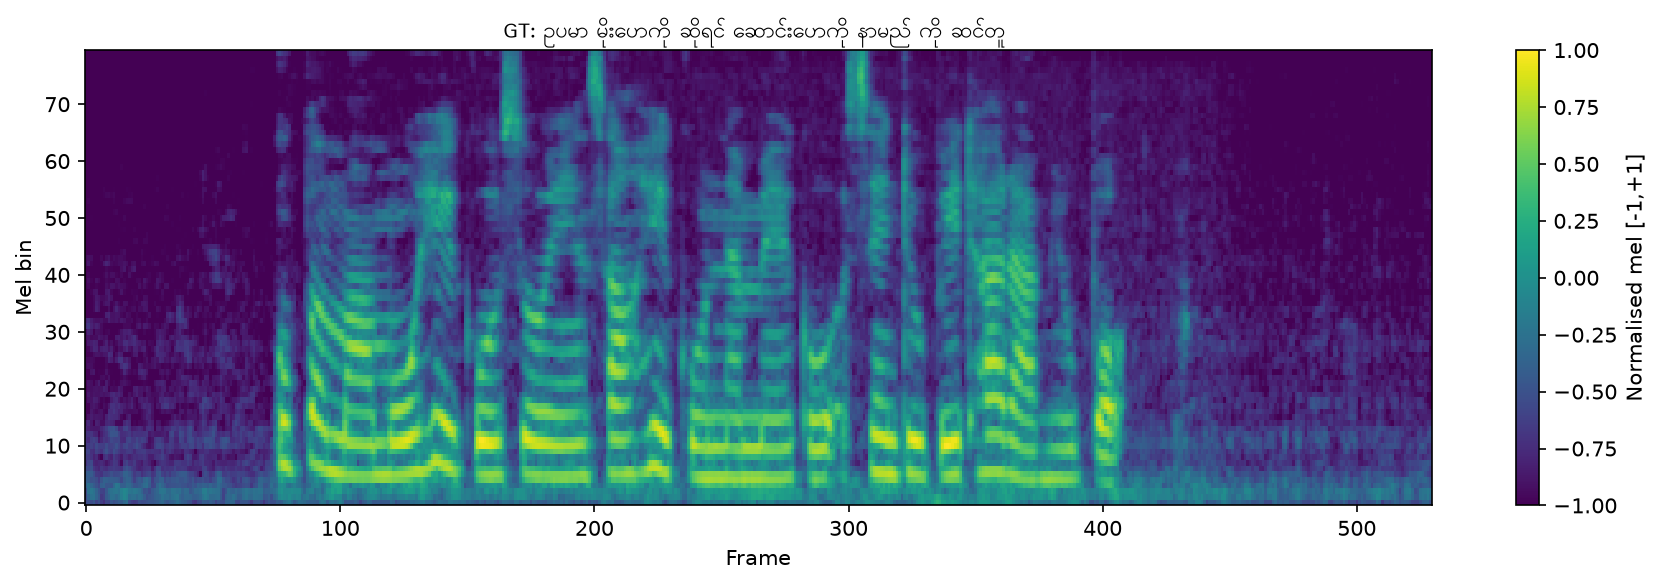

In [21]:
ipd.display(ipd.Audio(f"{GT_PATH}/gt_bur_8266_7413365509.wav"))
ipd.display(Image(filename=f"{GT_PATH}/gt_bur_8266_7413365509.png"))

### Example Sample 3 - Griffin-Lim

In [22]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage synth \
  --output_dir {OUTPUT} \
  --gt_sample_id bur_5932_6467856225 \
  --synth_out {GT_PATH}/gt_bur_5932_6467856225.wav \
  --no_neural_vocoder

2026-09-26 18:07:02  [INFO    ]  Vocoder: Griffin-Lim
2026-09-26 18:07:02  [INFO    ]  Found bur_5932_6467856225 in train
2026-09-26 18:07:02  [INFO    ]  GT text: ရုပ်ရှင်ကားကြီးတွေ ရိုက်ရင် ဖလင် က တအား ကုန်တယ်
2026-09-26 18:07:02  [INFO    ]  GT mel: min=-80.0 max=0.0 mean=-52.6 dB  shape=(317, 80)
2026-09-26 18:07:07  [INFO    ]  Mel plot → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/gt_bur_5932_6467856225.png
2026-09-26 18:07:07  [INFO    ]  GT audio → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/gt_bur_5932_6467856225.wav  (3.67s)

real	0m6.324s
user	0m11.169s
sys	0m0.390s


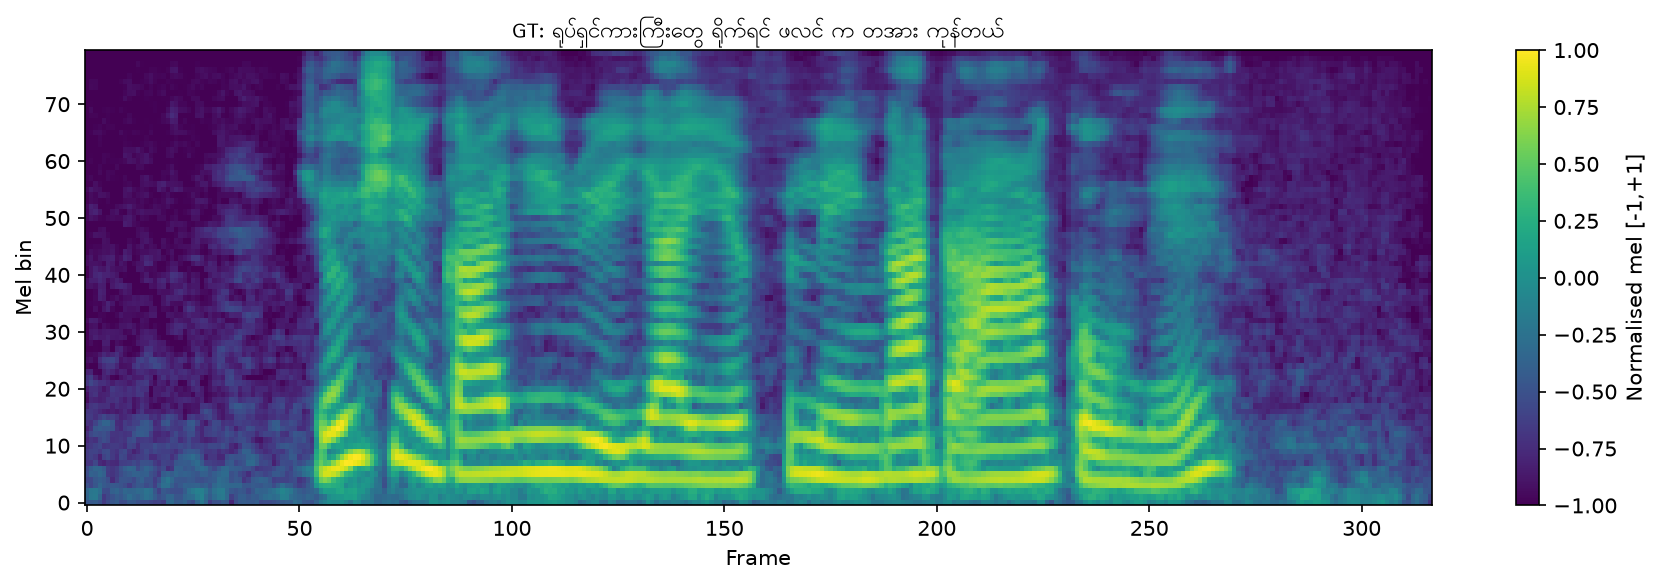

In [23]:
ipd.display(ipd.Audio(f"{GT_PATH}/gt_bur_5932_6467856225.wav"))
ipd.display(Image(filename=f"{GT_PATH}/gt_bur_5932_6467856225.png"))

## Testing (Prediction)

### Longer Prediction - Original Training Data Input

#### Best Model

In [24]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage synth \
  --output_dir {OUTPUT} \
  --gt_sample_id bur_5362_4875790905 \
  --synth_out {GT_PATH}/best_model_predicted_gt_bur_5362_4875790905.wav \
  --gt_compare \
  --save_mel \
  --no_neural_vocoder

2026-09-26 20:37:29  [INFO    ]  Vocoder: Griffin-Lim
2026-09-26 20:37:29  [INFO    ]  Found bur_5362_4875790905 in train
2026-09-26 20:37:29  [INFO    ]  GT text: ကျွန်တော် ကလည်း ဒိတ်ဒိတ်ကျဲ အောင်မြင်နေတဲ့ မင်းသား မှ မဟုတ်တာလေ
2026-09-26 20:37:29  [INFO    ]  GT mel: min=-80.0 max=0.0 mean=-57.5 dB  shape=(522, 80)
2026-09-26 20:37:30  [INFO    ]  Loaded TransformerTTSNAR from best_model.pt: epoch=43  dev=1.1272
2026-09-26 20:37:30  [INFO    ]  Synthesizing: 'ကျွန်တော် ကလည်း ဒိတ်ဒိတ်ကျဲ အောင်မြင်နေတဲ့ မင်းသား မှ မဟုတ်တာလေ'
2026-09-26 20:37:30  [INFO    ]    length   : 65 tokens × 7.3 fpc ≈ 472 frames expected  (speed=1.0)
2026-09-26 20:37:30  [INFO    ]    mel_norm : min=-1.006  max=0.478  mean=-0.413
2026-09-26 20:37:30  [INFO    ]    mel_db   : min=-80.0  max=-20.9  mean=-56.5 dB
2026-09-26 20:37:30  [INFO    ]    shape    : (458, 80)  (5.32s at default hop/sr)
2026-09-26 20:37:30  [INFO    ]    ✓ mel_db max=-20.9 dB — healthy
2026-09-26 20:37:30  [INFO    ]  Acoustic model: 315 ms


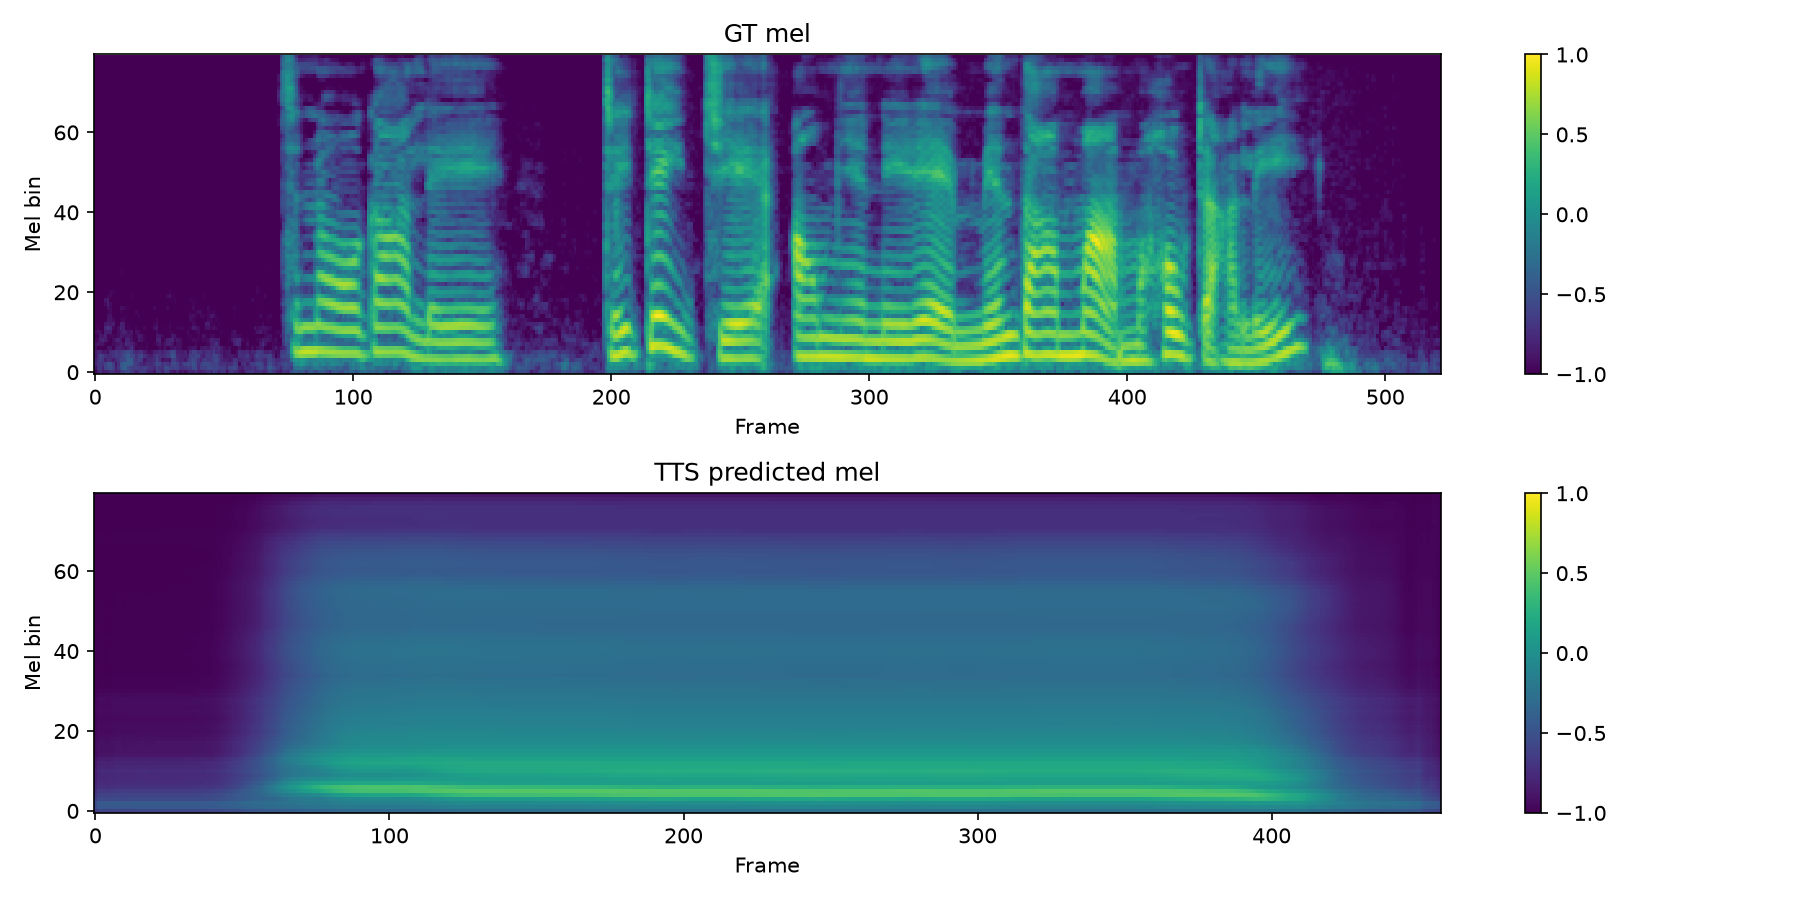

In [25]:
ipd.display(ipd.Audio(f"{GT_PATH}/best_model_predicted_gt_bur_5362_4875790905_GT.wav"))
ipd.display(ipd.Audio(f"{GT_PATH}/best_model_predicted_gt_bur_5362_4875790905.wav"))
ipd.display(Image(filename=f"{GT_PATH}/best_model_predicted_gt_bur_5362_4875790905_compare.png"))

#### Last Model (150 Epochs)

In [26]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage synth \
  --checkpoint {OUTPUT}/checkpoint_ep0150.pt \
  --output_dir {OUTPUT} \
  --gt_sample_id bur_5362_4875790905 \
  --synth_out {GT_PATH}/last_model_predicted_gt_bur_5362_4875790905.wav \
  --gt_compare \
  --save_mel \
  --no_neural_vocoder

2026-09-26 20:53:14  [INFO    ]  Vocoder: Griffin-Lim
2026-09-26 20:53:14  [INFO    ]  Found bur_5362_4875790905 in train
2026-09-26 20:53:14  [INFO    ]  GT text: ကျွန်တော် ကလည်း ဒိတ်ဒိတ်ကျဲ အောင်မြင်နေတဲ့ မင်းသား မှ မဟုတ်တာလေ
2026-09-26 20:53:14  [INFO    ]  GT mel: min=-80.0 max=0.0 mean=-57.5 dB  shape=(522, 80)
2026-09-26 20:53:15  [INFO    ]  Loaded TransformerTTSNAR from checkpoint_ep0150.pt: epoch=150  dev=1.1467
2026-09-26 20:53:15  [INFO    ]  Synthesizing: 'ကျွန်တော် ကလည်း ဒိတ်ဒိတ်ကျဲ အောင်မြင်နေတဲ့ မင်းသား မှ မဟုတ်တာလေ'
2026-09-26 20:53:15  [INFO    ]    length   : 65 tokens × 7.3 fpc ≈ 472 frames expected  (speed=1.0)
2026-09-26 20:53:16  [INFO    ]    mel_norm : min=-1.020  max=0.490  mean=-0.430
2026-09-26 20:53:16  [INFO    ]    mel_db   : min=-80.0  max=-20.4  mean=-57.2 dB
2026-09-26 20:53:16  [INFO    ]    shape    : (423, 80)  (4.91s at default hop/sr)
2026-09-26 20:53:16  [INFO    ]    ✓ mel_db max=-20.4 dB — healthy
2026-09-26 20:53:16  [INFO    ]  Acoustic model:

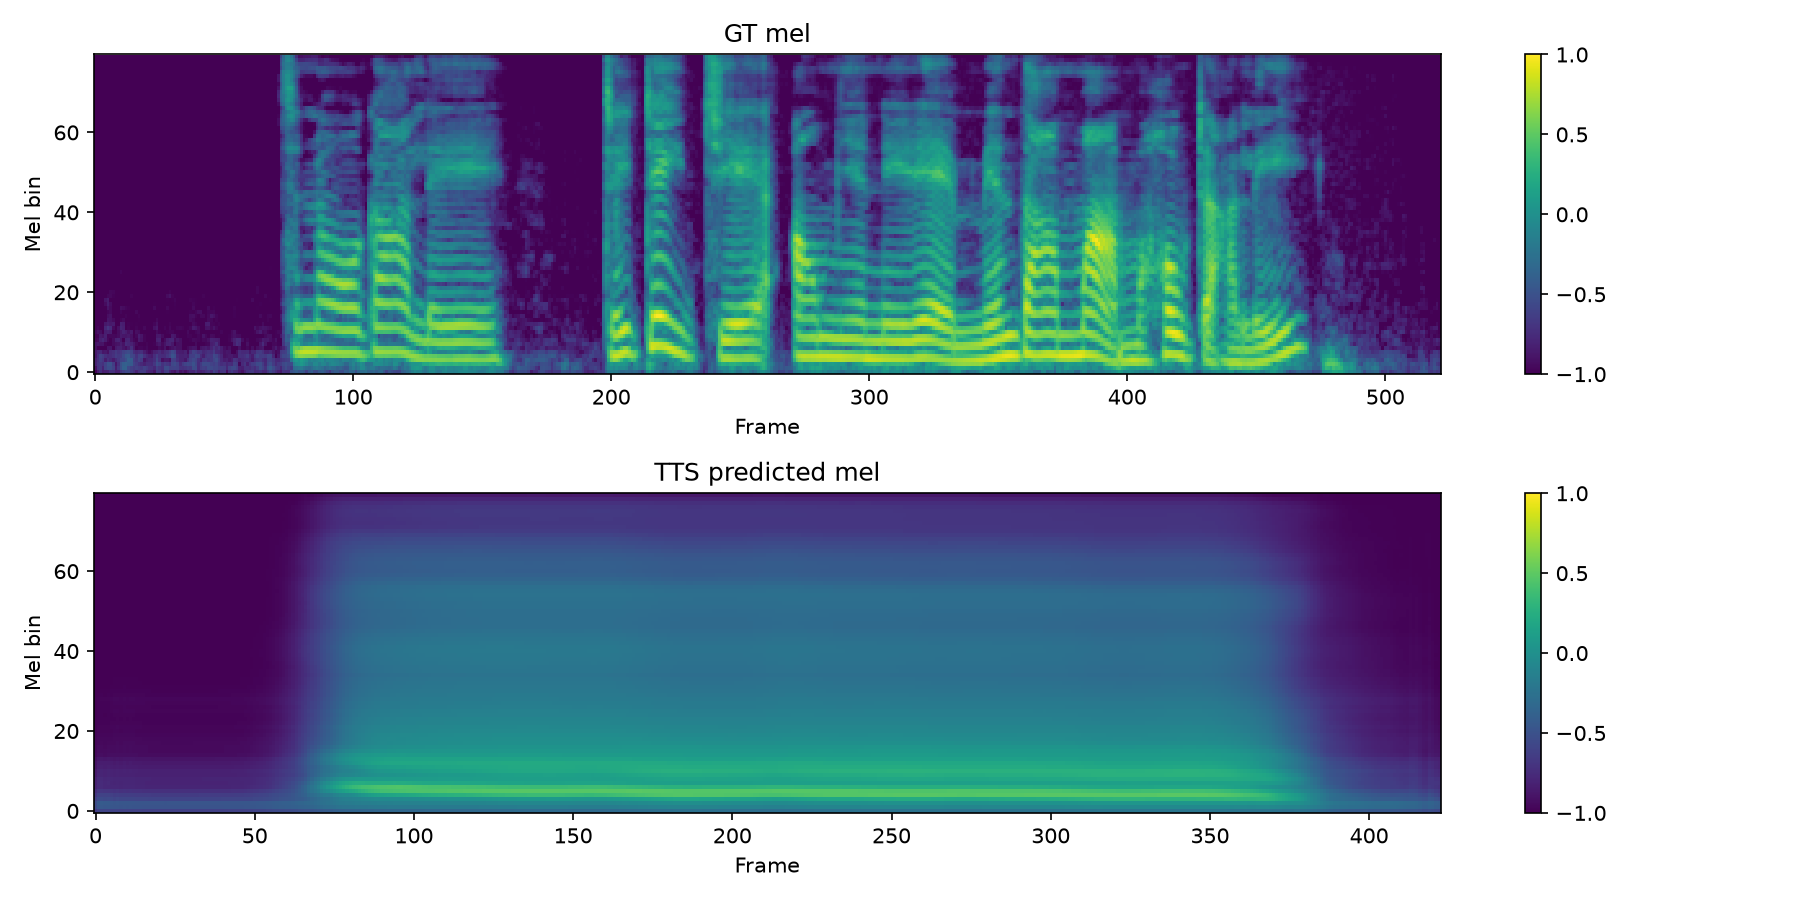

In [27]:
ipd.display(ipd.Audio(f"{GT_PATH}/last_model_predicted_gt_bur_5362_4875790905_GT.wav"))
ipd.display(ipd.Audio(f"{GT_PATH}/last_model_predicted_gt_bur_5362_4875790905.wav"))
ipd.display(Image(filename=f"{GT_PATH}/last_model_predicted_gt_bur_5362_4875790905_compare.png"))

### Shorter Prediction - Arbitrary Text Input (No Reference to Test Against)

#### Best Model

In [28]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage synth \
  --output_dir {OUTPUT} \
  --synth_text "ရုပ်ရှင်ကားကြီးတွေ" \
  --synth_out {GT_PATH}/best_model_pred_custom_input.wav \
  --save_mel \
  --no_neural_vocoder

2026-09-26 21:17:33  [INFO    ]  Vocoder: Griffin-Lim
2026-09-26 21:17:34  [INFO    ]  Loaded TransformerTTSNAR from best_model.pt: epoch=43  dev=1.1272
2026-09-26 21:17:34  [INFO    ]  Synthesizing: 'ရုပ်ရှင်ကားကြီးတွေ'
2026-09-26 21:17:34  [INFO    ]    length   : 20 tokens × 7.3 fpc ≈ 145 frames expected  (speed=1.0)
2026-09-26 21:17:34  [INFO    ]    mel_norm : min=-1.129  max=0.504  mean=-0.480
2026-09-26 21:17:34  [INFO    ]    mel_db   : min=-80.0  max=-19.8  mean=-59.2 dB
2026-09-26 21:17:34  [INFO    ]    shape    : (151, 80)  (1.75s at default hop/sr)
2026-09-26 21:17:34  [INFO    ]    ✓ mel_db max=-19.8 dB — healthy
2026-09-26 21:17:34  [INFO    ]  Acoustic model: 257 ms
2026-09-26 21:17:35  [INFO    ]  Mel plot → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/best_model_pred_custom_input.png
2026-09-26 21:17:35  [INFO    ]  Pred mel → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/best_model_pred_custom_input.npy  shap

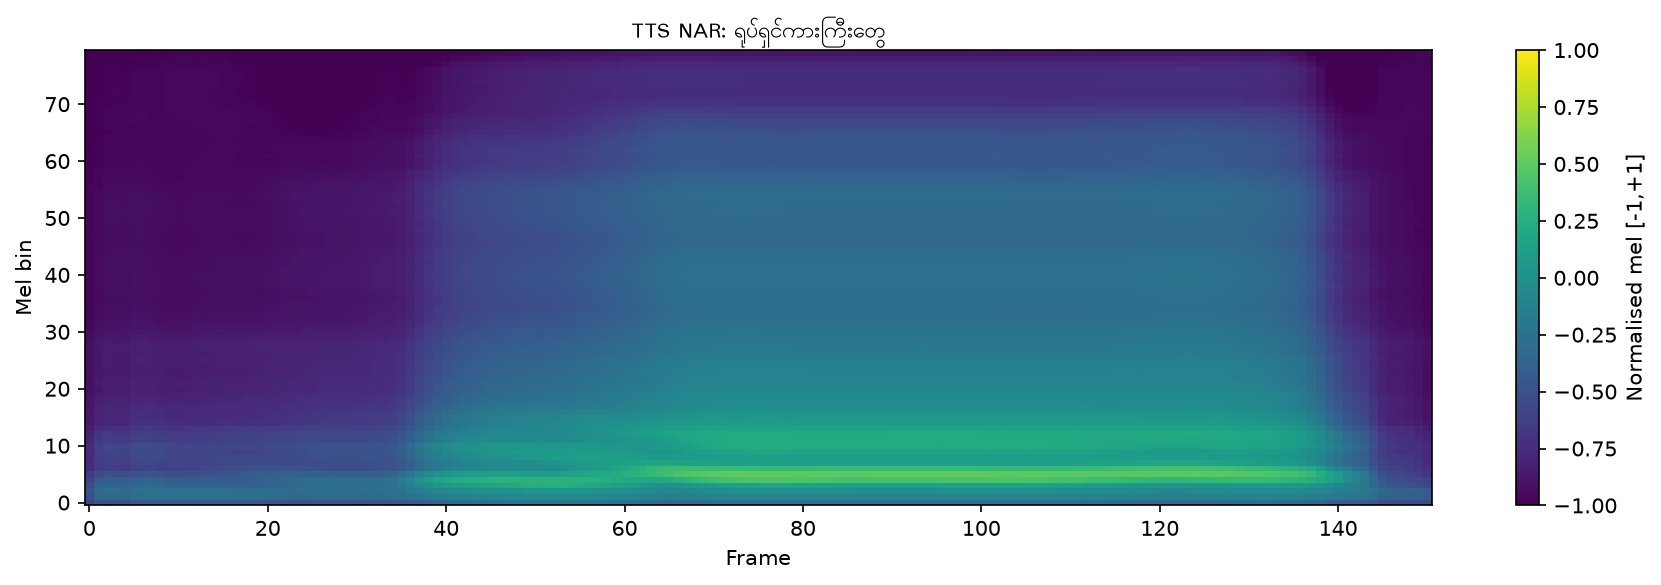

In [29]:
ipd.display(ipd.Audio(f"{GT_PATH}/best_model_pred_custom_input.wav"))
ipd.display(Image(filename=f"{GT_PATH}/best_model_pred_custom_input.png"))

#### Last Model (150 Epochs)

In [30]:
!time python {SRC}/myanmar_tts_transformer_nar.py --stage synth \
  --checkpoint {OUTPUT}/checkpoint_ep0150.pt \
  --output_dir {OUTPUT} \
  --synth_text "ရုပ်ရှင်ကားကြီးတွေ" \
  --synth_out {GT_PATH}/last_model_pred_custom_input.wav \
  --save_mel \
  --no_neural_vocoder

2026-09-26 21:17:48  [INFO    ]  Vocoder: Griffin-Lim
2026-09-26 21:17:49  [INFO    ]  Loaded TransformerTTSNAR from checkpoint_ep0150.pt: epoch=150  dev=1.1467
2026-09-26 21:17:49  [INFO    ]  Synthesizing: 'ရုပ်ရှင်ကားကြီးတွေ'
2026-09-26 21:17:49  [INFO    ]    length   : 20 tokens × 7.3 fpc ≈ 145 frames expected  (speed=1.0)
2026-09-26 21:17:49  [INFO    ]    mel_norm : min=-1.080  max=0.505  mean=-0.436
2026-09-26 21:17:49  [INFO    ]    mel_db   : min=-80.0  max=-19.8  mean=-57.4 dB
2026-09-26 21:17:49  [INFO    ]    shape    : (150, 80)  (1.74s at default hop/sr)
2026-09-26 21:17:49  [INFO    ]    ✓ mel_db max=-19.8 dB — healthy
2026-09-26 21:17:49  [INFO    ]  Acoustic model: 254 ms
2026-09-26 21:17:50  [INFO    ]  Mel plot → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/last_model_pred_custom_input.png
2026-09-26 21:17:50  [INFO    ]  Pred mel → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/last_model_pred_custom_input.n

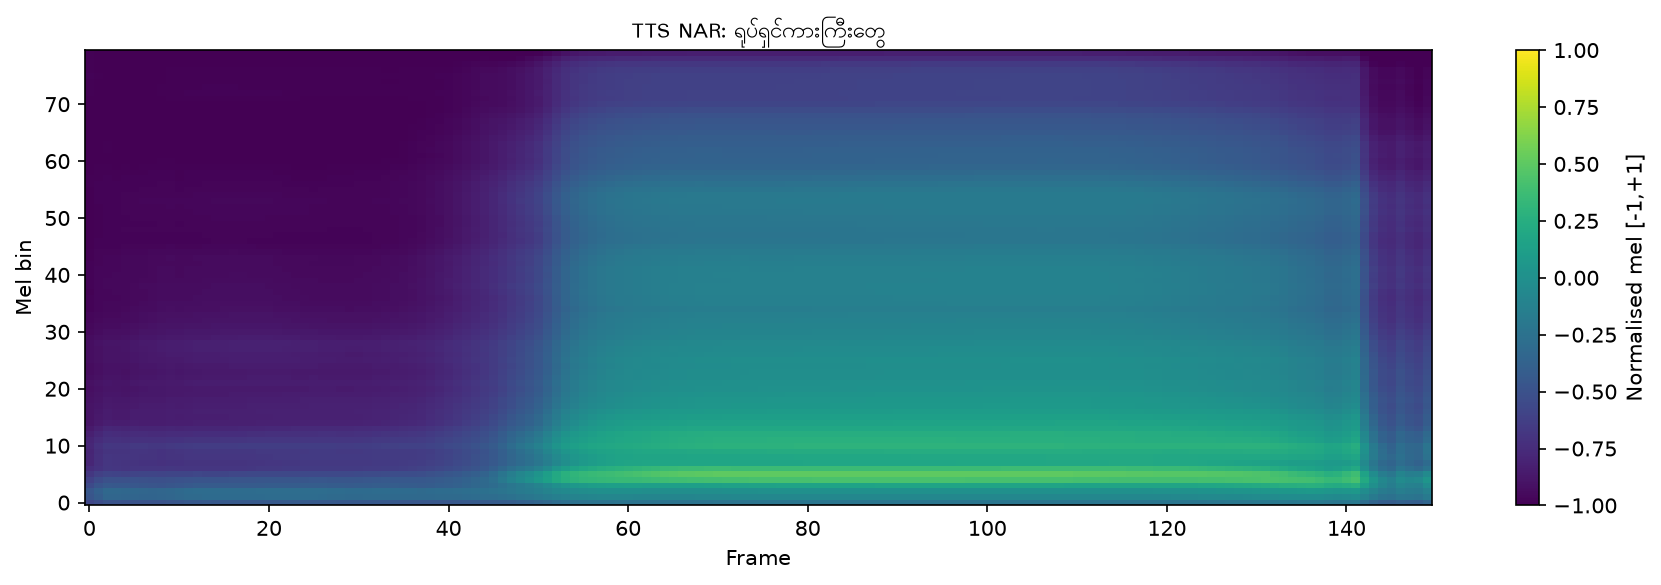

In [31]:
ipd.display(ipd.Audio(f"{GT_PATH}/last_model_pred_custom_input.wav"))
ipd.display(Image(filename=f"{GT_PATH}/last_model_pred_custom_input.png"))

## Error Analysis: Original Training Data vs. Predicted Training Data

### Best Model

In [32]:
!time python {SRC}/plot.py mel_error \
  --gt_mel {OUTPUT}/mels/bur_5362_4875790905.npy \
  --pred_mel {GT_PATH}/best_model_predicted_gt_bur_5362_4875790905.npy \
  --save {PLOTS}/best_model_mel_err_bur_5362_4875790905.png

saved → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/plots/best_model_mel_err_bur_5362_4875790905.png
GT   = /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/mels/bur_5362_4875790905.npy
pred = /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/best_model_predicted_gt_bur_5362_4875790905.npy
MAE  = 0.3286  (T=458)
plot → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/plots/best_model_mel_err_bur_5362_4875790905.png

real	0m1.022s
user	0m2.094s
sys	0m0.090s


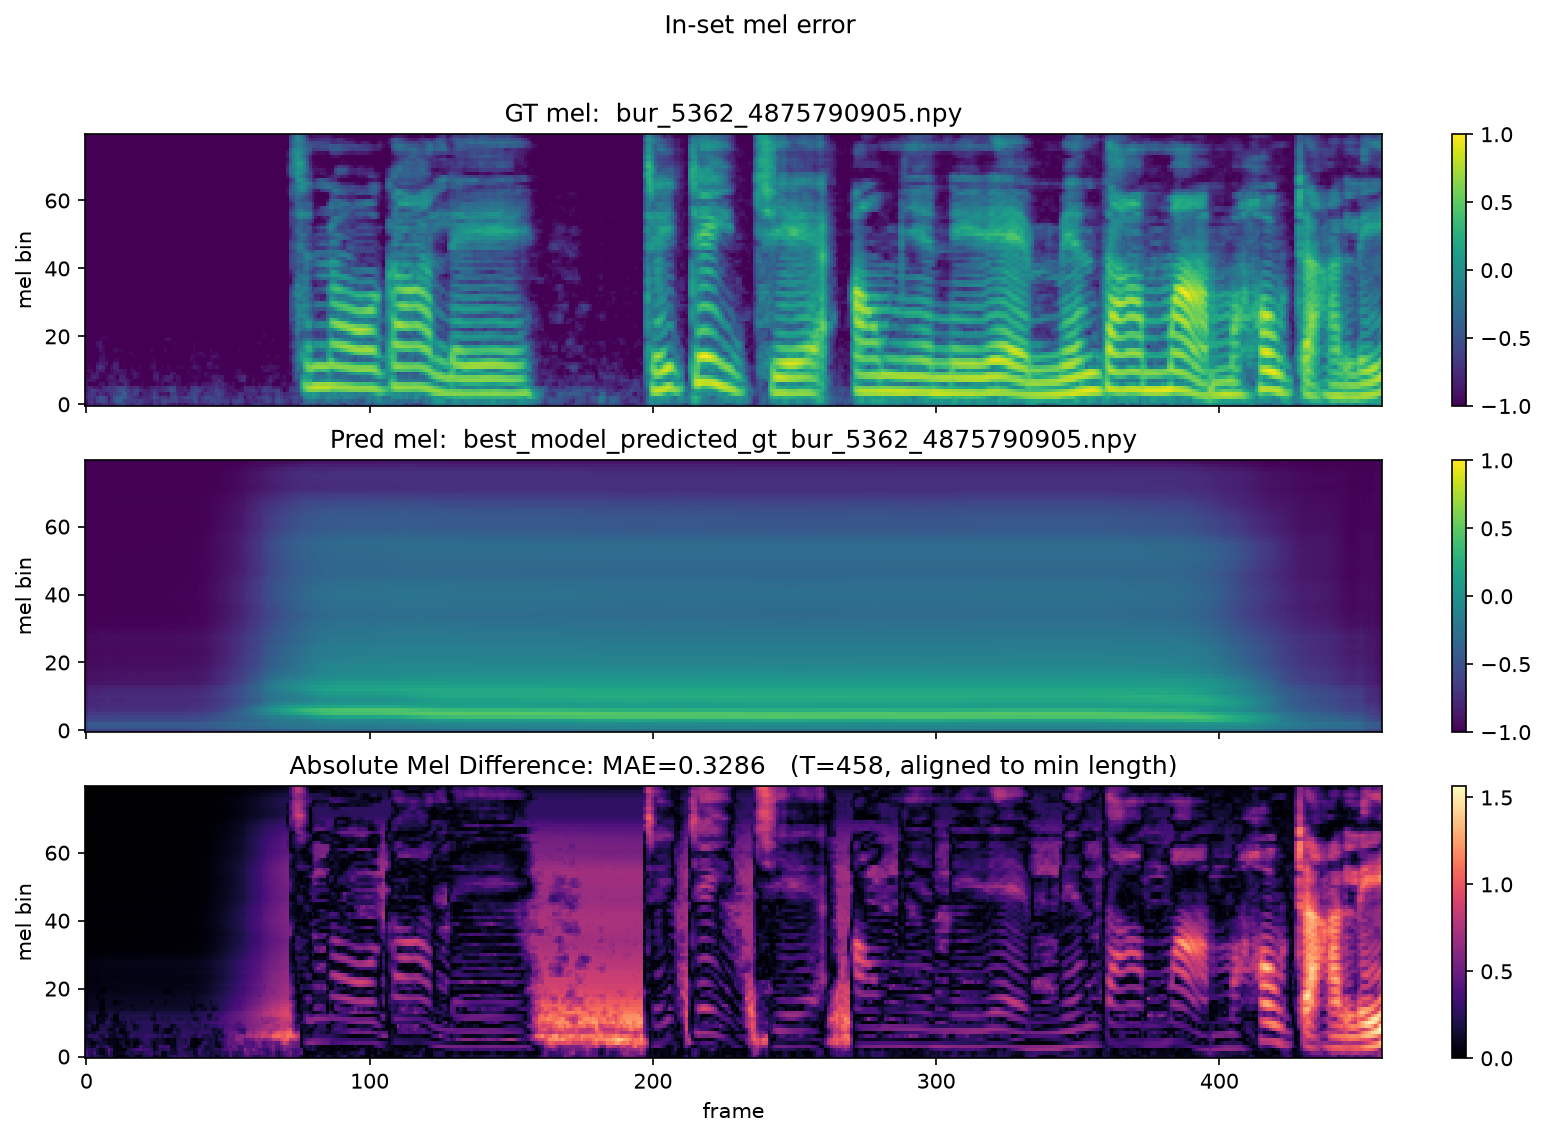

In [33]:
ipd.display(Image(filename=f"{PLOTS}/best_model_mel_err_bur_5362_4875790905.png"))

### Last Model (150 Epochs)

In [34]:
!time python {SRC}/plot.py mel_error \
  --gt_mel {OUTPUT}/mels/bur_5362_4875790905.npy \
  --pred_mel {GT_PATH}/last_model_predicted_gt_bur_5362_4875790905.npy \
  --save {PLOTS}/last_model_mel_err_bur_5362_4875790905.png

saved → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/plots/last_model_mel_err_bur_5362_4875790905.png
GT   = /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/mels/bur_5362_4875790905.npy
pred = /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/last_model_predicted_gt_bur_5362_4875790905.npy
MAE  = 0.3283  (T=423)
plot → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/plots/last_model_mel_err_bur_5362_4875790905.png

real	0m1.022s
user	0m2.155s
sys	0m0.073s


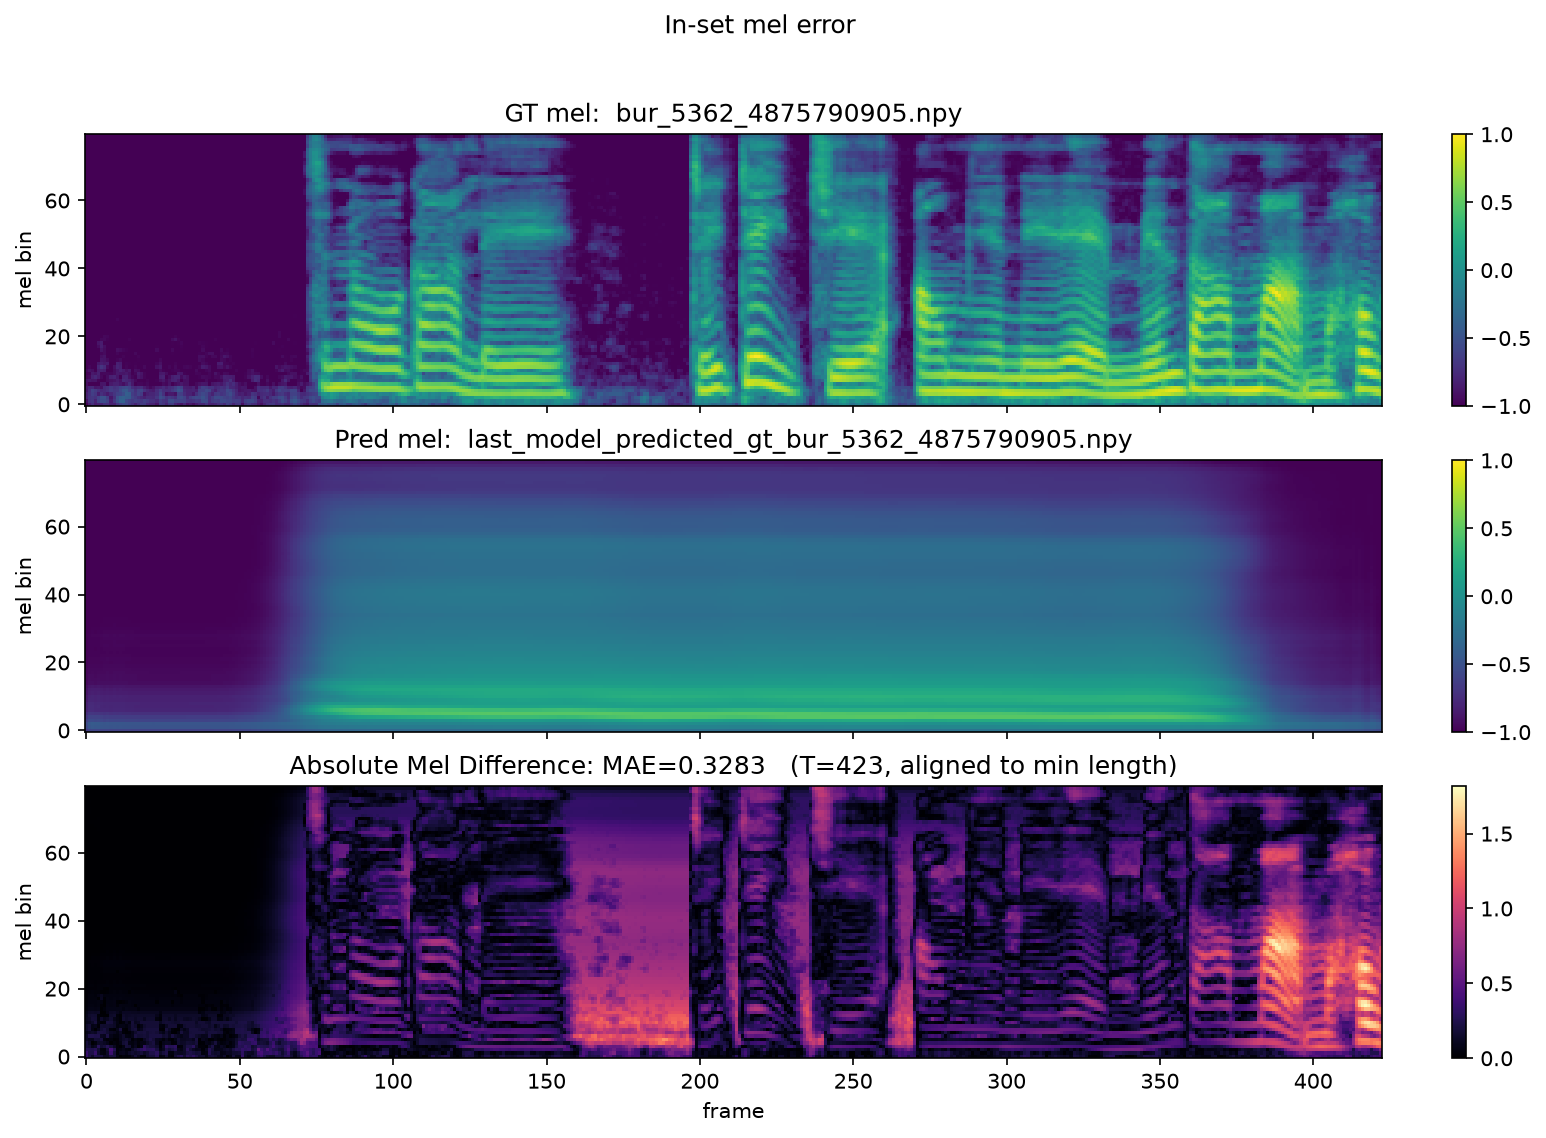

In [35]:
ipd.display(Image(filename=f"{PLOTS}/last_model_mel_err_bur_5362_4875790905.png"))

## Error Analysis: Best Model Prediction vs. Last Model Prediction

### Prediction Comparison on Original Training Data Input

In [36]:
!time python {SRC}/plot.py mel_error \
  --gt_mel {GT_PATH}/best_model_predicted_gt_bur_5362_4875790905.npy \
  --pred_mel {GT_PATH}/last_model_predicted_gt_bur_5362_4875790905.npy \
  --save {PLOTS}/best_v_last_training_mel_err_bur_5362_4875790905.png \
  --titles "Best Model mel" "Last Model (150 eps) mel" "|Absolute Difference|" "Mel error"

saved → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/plots/best_v_last_training_mel_err_bur_5362_4875790905.png
GT   = /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/best_model_predicted_gt_bur_5362_4875790905.npy
pred = /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/last_model_predicted_gt_bur_5362_4875790905.npy
MAE  = 0.0793  (T=423)
plot → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/plots/best_v_last_training_mel_err_bur_5362_4875790905.png

real	0m0.984s
user	0m1.953s
sys	0m0.078s


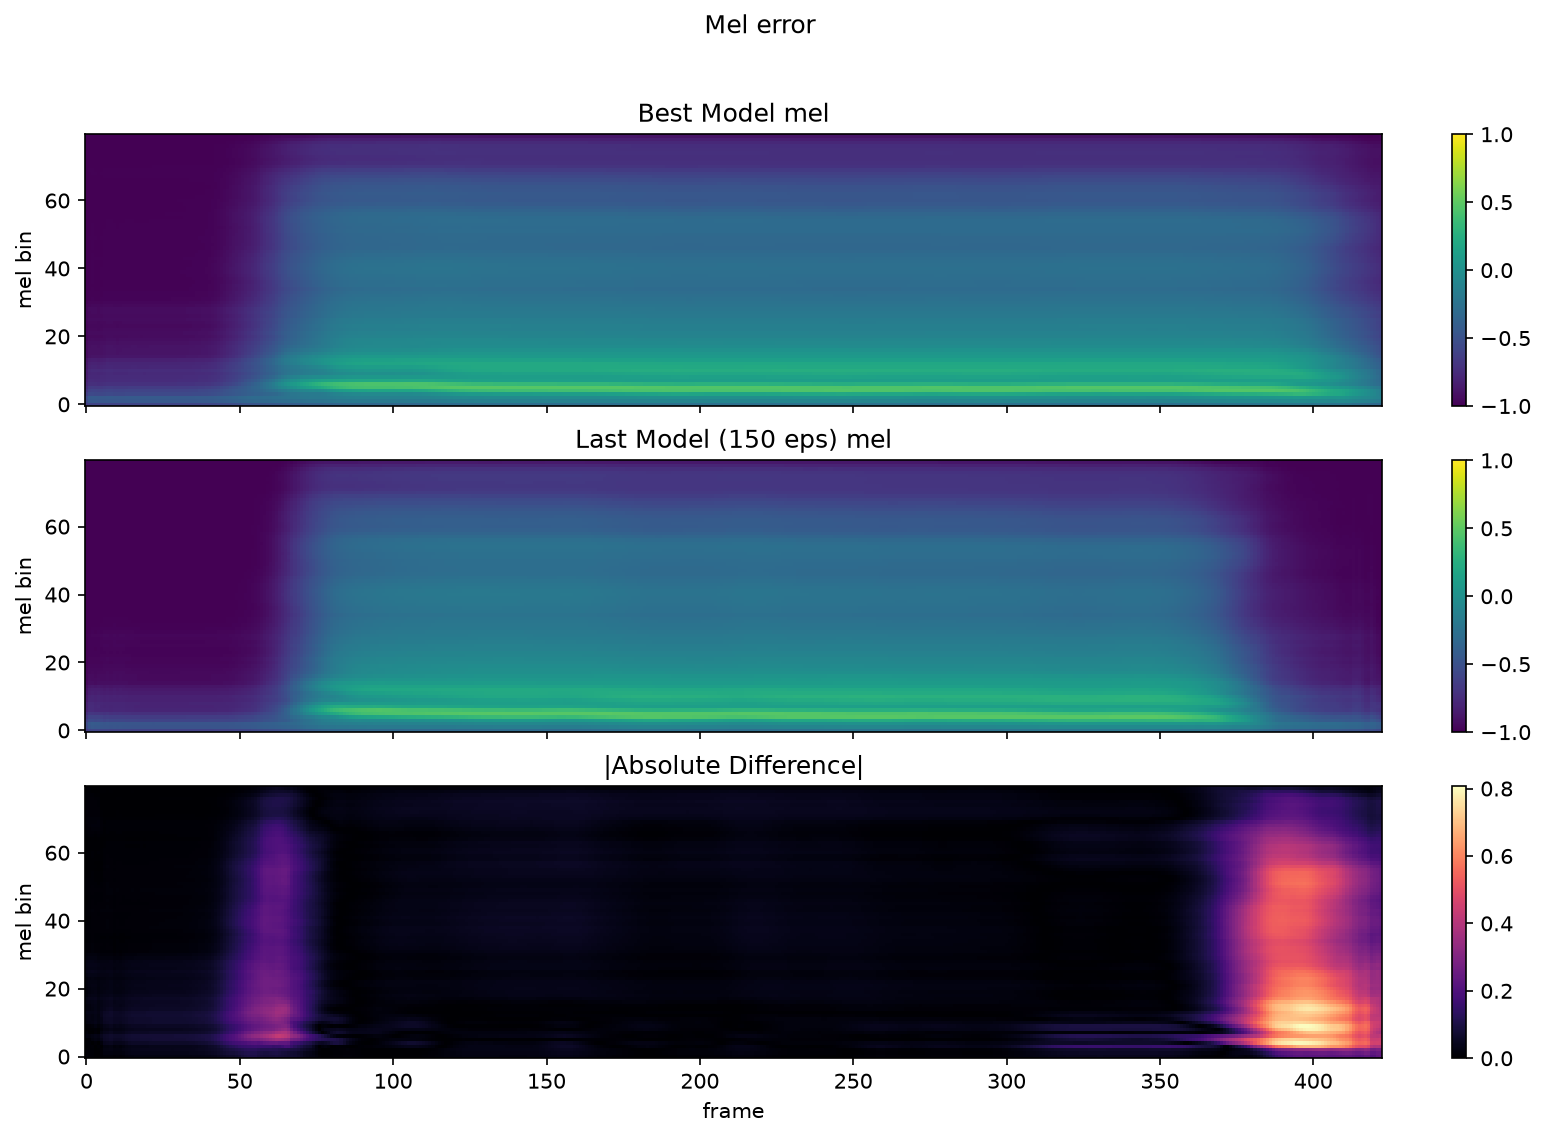

In [37]:
ipd.display(Image(filename=f"{PLOTS}/best_v_last_training_mel_err_bur_5362_4875790905.png"))

### Prediction Comparison on Arbitrary Text Input

In [38]:
!time python {SRC}/plot.py mel_error \
  --gt_mel {GT_PATH}/best_model_pred_custom_input.npy \
  --pred_mel {GT_PATH}/last_model_pred_custom_input.npy \
  --save {PLOTS}/best_v_last_custom_mel_err_bur_5362_4875790905.png \
  --titles "Best Model mel" "Last Model (150 eps) mel" "|Absolute Difference|" "Mel error"

saved → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/plots/best_v_last_custom_mel_err_bur_5362_4875790905.png
GT   = /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/best_model_pred_custom_input.npy
pred = /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/gt_output/last_model_pred_custom_input.npy
MAE  = 0.1088  (T=150)
plot → /home/lawun330/PROJECTS/basic-ASR-and-TTS/tts_output/nar_version/plots/best_v_last_custom_mel_err_bur_5362_4875790905.png

real	0m0.977s
user	0m1.997s
sys	0m0.074s


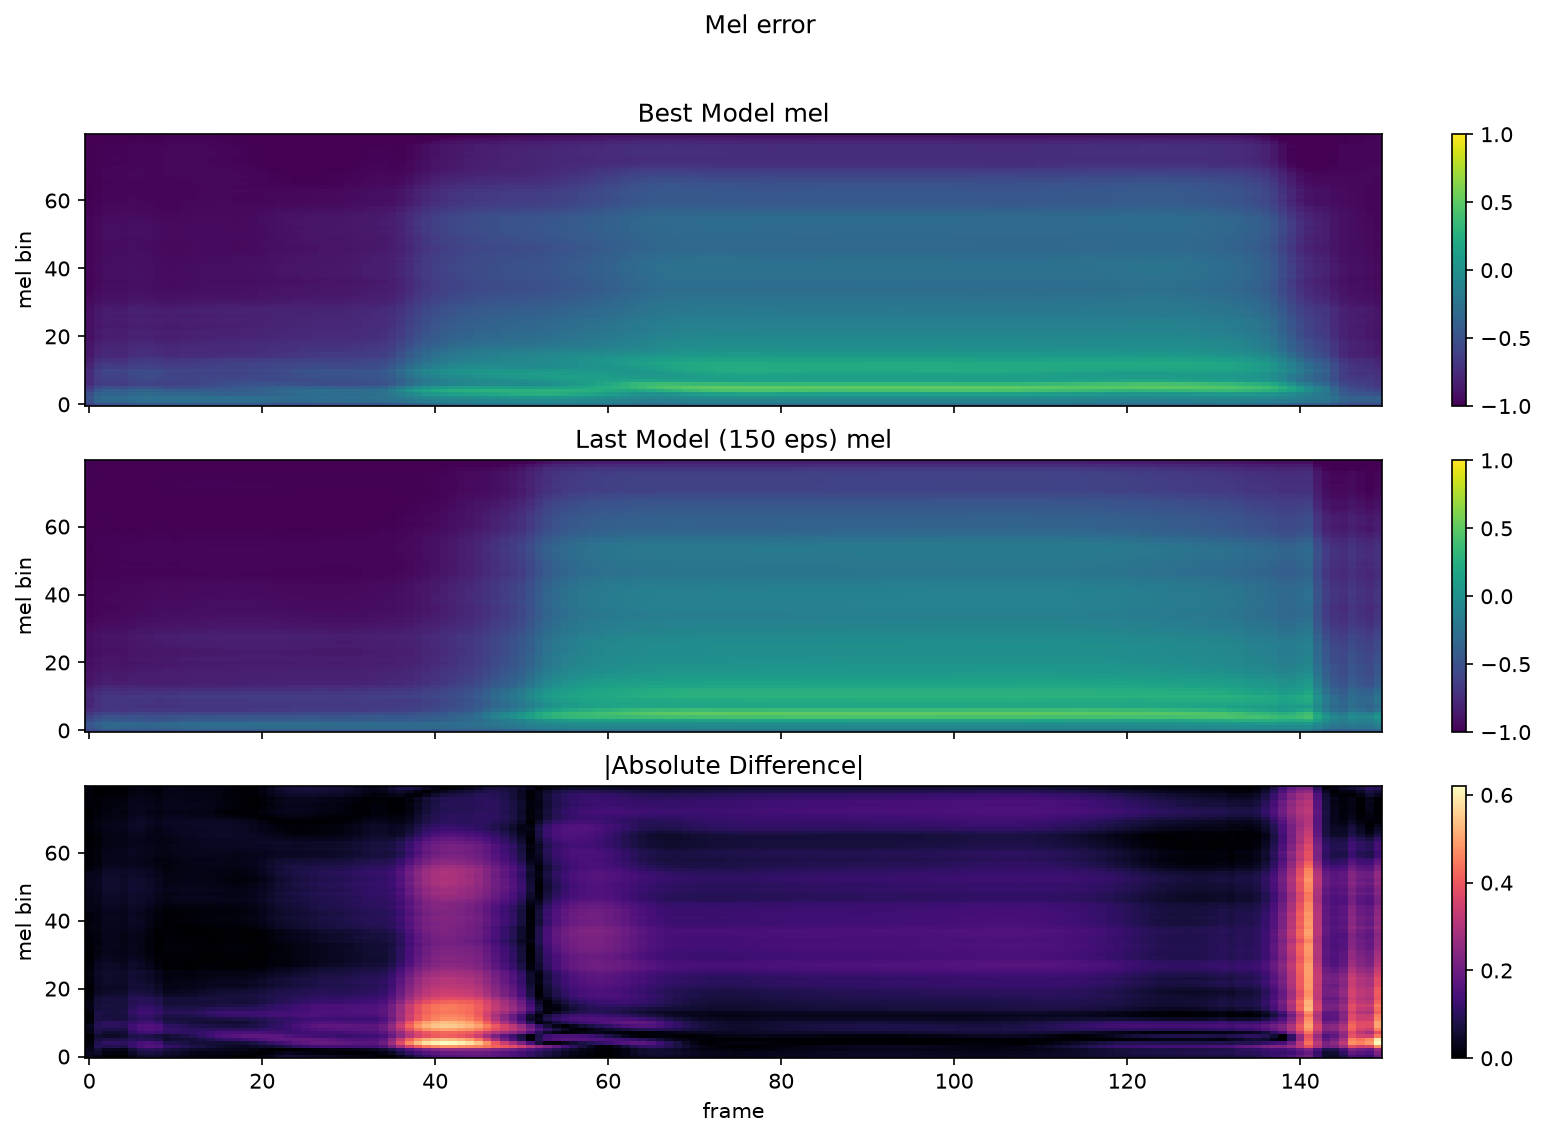

In [39]:
ipd.display(Image(filename=f"{PLOTS}/best_v_last_custom_mel_err_bur_5362_4875790905.png"))